# Simple NLP Lab: Text Classification with BERT

This notebook demonstrates a **simple BERT-based text classification pipeline** on the **BBC News dataset**.

## What this notebook covers
- Loading and exploring the dataset
- Encoding labels
- Splitting data into train / validation / test sets
- Tokenizing text using **BERT tokenizer**
- Fine-tuning **BERT** for classification using **PyTorch**
- Plotting:
  - training and validation loss
  - training and validation accuracy
  - training and validation F1-score
- Evaluating with:
  - classification report
  - confusion matrix
- Predicting the class of a custom text sample

> **Note:** This version avoids TensorFlow entirely, so it is suitable for environments where TensorFlow is not installed.


## 1. Install required libraries

Run the next cell only if some packages are missing in your environment.


In [ ]:
# Run this cell only if needed
# %pip install -q torch transformers scikit-learn pandas matplotlib seaborn tqdm


## 2. Import libraries and set random seed

In [3]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.10.0+cpu
Device: cpu


## 3. Load the dataset

The notebook looks for the dataset in the current folder first, then in common fallback locations.


In [4]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\bbc-text.csv")
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


## 4. Inspect the dataset

In [5]:
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df["category"].value_counts())

Dataset shape: (2225, 2)

Columns: ['category', 'text']

Missing values:
 category    0
text        0
dtype: int64

Class distribution:
 category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


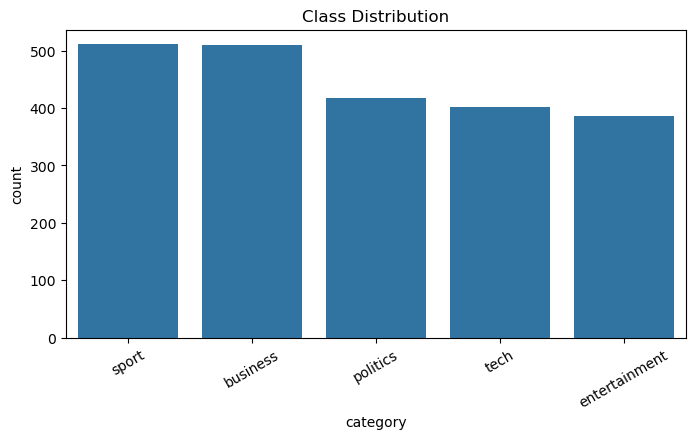

In [6]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="category", order=df["category"].value_counts().index)
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.show()

## 5. Prepare labels and split the dataset

In [7]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])

label_names = list(label_encoder.classes_)
num_labels = len(label_names)

print("Classes:", label_names)
print("Number of classes:", num_labels)

X = df["text"].astype(str).tolist()
y = df["label"].values

# Train: 70%, Validation: 15%, Test: 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Classes: ['business', 'entertainment', 'politics', 'sport', 'tech']
Number of classes: 5
Train size: 1557
Validation size: 334
Test size: 334


## 6. Tokenization with BERT

We use the **bert-base-uncased** tokenizer to convert raw text into token IDs and attention masks.


In [8]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=MAX_LEN)
val_encodings = tokenizer(X_val, truncation=True, padding=True, max_length=MAX_LEN)
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=MAX_LEN)

print("Tokenization complete.")

Tokenization complete.


## 7. Create a PyTorch dataset and dataloaders

In [9]:
class BBCDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

train_dataset = BBCDataset(train_encodings, y_train)
val_dataset = BBCDataset(val_encodings, y_val)
test_dataset = BBCDataset(test_encodings, y_test)

BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Dataloaders ready.")

Dataloaders ready.


## 8. Build the BERT classification model

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)
model.to(device)

print("Model loaded successfully.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.


## 9. Configure training

For a lab demo, **2 epochs** are usually enough to show the workflow.  
If you want stronger results, increase the number of epochs.


In [11]:
EPOCHS = 3
LEARNING_RATE = 2e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

## 10. Define helper functions

In [12]:
def run_epoch(model, data_loader, optimizer=None, scheduler=None, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    losses = []
    all_preds = []
    all_labels = []

    for batch in tqdm(data_loader, leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            logits = outputs.logits

            if train_mode:
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

        preds = torch.argmax(logits, dim=1)

        losses.append(loss.item())
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = np.mean(losses)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, acc, f1, all_labels, all_preds

## 11. Train the model

In [13]:
for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc, train_f1, _, _ = run_epoch(
        model, train_loader, optimizer=optimizer, scheduler=scheduler, train_mode=True
    )

    val_loss, val_acc, val_f1, _, _ = run_epoch(
        model, val_loader, train_mode=False
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print("-" * 60)

Epoch 1/3


  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

Train Loss: 0.5665 | Train Acc: 0.8504 | Train F1: 0.8497
Val   Loss: 0.1061 | Val   Acc: 0.9790 | Val   F1: 0.9791
------------------------------------------------------------
Epoch 2/3


  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

Train Loss: 0.0853 | Train Acc: 0.9865 | Train F1: 0.9865
Val   Loss: 0.0797 | Val   Acc: 0.9790 | Val   F1: 0.9790
------------------------------------------------------------
Epoch 3/3


  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

Train Loss: 0.0417 | Train Acc: 0.9942 | Train F1: 0.9942
Val   Loss: 0.0720 | Val   Acc: 0.9790 | Val   F1: 0.9791
------------------------------------------------------------


## 12. Plot loss, accuracy, and F1-score curves

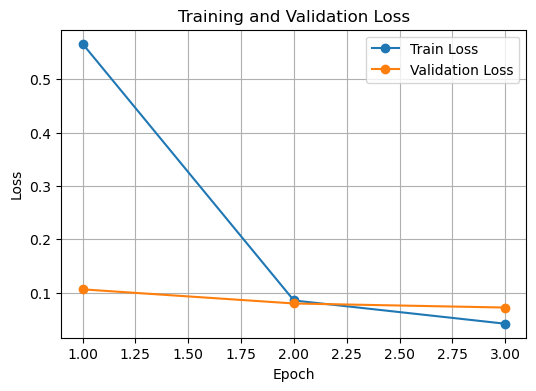

In [14]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

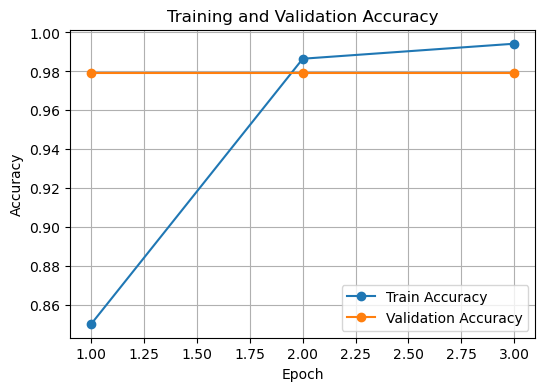

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], marker="o", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

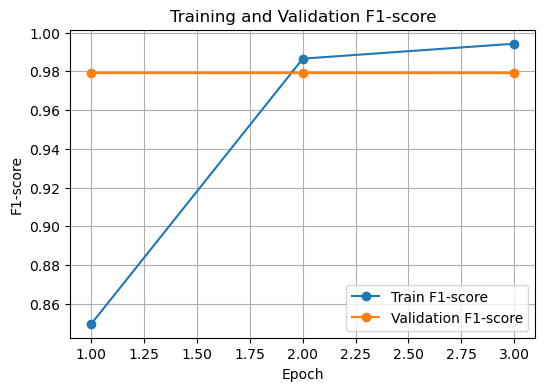

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, history["train_f1"], marker="o", label="Train F1-score")
plt.plot(epochs_range, history["val_f1"], marker="o", label="Validation F1-score")
plt.title("Training and Validation F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()

## 13. Evaluate on the test set

In [17]:
test_loss, test_acc, test_f1, y_true, y_pred = run_epoch(
    model, test_loader, train_mode=False
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Weighted F1-score: {test_f1:.4f}")

  0%|          | 0/42 [00:00<?, ?it/s]

Test Loss: 0.0657
Test Accuracy: 0.9760
Test Weighted F1-score: 0.9760


In [18]:
print(classification_report(y_true, y_pred, target_names=label_names))

               precision    recall  f1-score   support

     business       0.94      0.99      0.96        77
entertainment       0.98      0.98      0.98        58
     politics       0.98      0.98      0.98        62
        sport       1.00      1.00      1.00        77
         tech       0.98      0.92      0.95        60

     accuracy                           0.98       334
    macro avg       0.98      0.97      0.98       334
 weighted avg       0.98      0.98      0.98       334



## 14. Confusion matrix

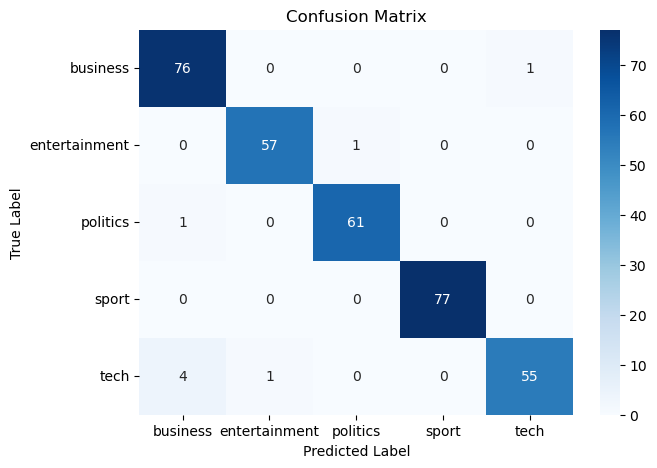

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 15. Predict a custom text sample

In [20]:
def predict_text(text, model, tokenizer, label_encoder, max_len=128):
    model.eval()
    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_label = torch.argmax(probs, dim=1).item()

    predicted_class = label_encoder.inverse_transform([pred_label])[0]
    return predicted_class, probs.cpu().numpy().flatten()

sample_text = "The government announced new economic policies and parliament debated the national budget."
predicted_class, probabilities = predict_text(sample_text, model, tokenizer, label_encoder)

print("Text:", sample_text)
print("Predicted class:", predicted_class)
print("\nClass probabilities:")
for class_name, prob in zip(label_names, probabilities):
    print(f"{class_name}: {prob:.4f}")

Text: The government announced new economic policies and parliament debated the national budget.
Predicted class: business

Class probabilities:
business: 0.9653
entertainment: 0.0046
politics: 0.0200
sport: 0.0041
tech: 0.0059
